# Dotting accuracy vs. position in word

This notebook correlates each dotting method's per-letter accuracy with the **position of the letter inside its word** on the test set.

Why position matters: Arabic letters take different shapes (initial / medial / final / isolated) depending on where they sit inside a word, and the surrounding linguistic context also varies by position (prefixes at the start, suffixes at the end). Different model families may exploit those signals differently — character-level neural models see local context symmetrically, n-grams condition only on the left context.

**Methods compared** — the per-position families only (best per family by lowest avg DOER, matching [rasm_substitution_analysis.ipynb](rasm_substitution_analysis.ipynb)):
- LSTM (sequence labeling)
- N-gram
- Transformer
- CANINE

LLMs are excluded — their outputs are not letter-aligned to the input (they drop/insert tokens), so per-letter position labels would be meaningless.

**Position scheme** (per ambiguous-Rasm position, where a *word* is a whitespace-separated token):
- **isolated** — word has exactly 1 character
- **initial** — first character of a multi-char word
- **medial** — interior character
- **final** — last character of a multi-char word

We also report a **relative position curve**: accuracy binned by `index_in_word / (word_length - 1)`, which lets us see whether errors concentrate at one end or the other.

All analysis is restricted to positions where the source dotless char is an **ambiguous Rasm** (15 Rasms — same set as in the sister notebook), since unambiguous letters are trivially correct.

In [1]:
import glob
import json
import os
from collections import defaultdict

import numpy as np
import pandas as pd
import pyarabic.araby as araby
from tabulate import tabulate

from tnqeet import constants
from tnqeet import remove_dots


def find_repo_root(start=None):
    cur = os.path.abspath(start or os.getcwd())
    for _ in range(8):
        if os.path.isdir(os.path.join(cur, "tnqeet", "dotting_models")):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    raise RuntimeError(f"Could not locate repo root from {os.getcwd()}")


REPO_ROOT = find_repo_root()
EVAL_ROOT = os.path.join(REPO_ROOT, "tnqeet", "dotting_models")
DATASET_NAME = "test_dataset"

REPO_ROOT

'/raid_storage/SLURM/home/slurm_majedalshaibani/Projects/tnqeet'

## Ambiguous Rasms

In [2]:
RASM_TO_DOTTED = defaultdict(list)
for dotted, rasm in constants.LETTERS_MAPPING.items():
    RASM_TO_DOTTED[rasm].append(dotted)

AMBIGUOUS_RASMS = [r for r in constants.ARABIC_RASMS if constants.is_ambigous_rasm(r)]
VALID_TARGETS = {r: RASM_TO_DOTTED[r] for r in AMBIGUOUS_RASMS}
AMBIGUOUS_SET = set(AMBIGUOUS_RASMS)

RASM_NAMES = {
    constants.ALEF_RASM: "ALEF",
    constants.BAA_RASM: "BAA",
    constants.JEEM_RASM: "JEEM",
    constants.DAL_RASM: "DAL",
    constants.RAA_RASM: "RAA",
    constants.SEEN_RASM: "SEEN",
    constants.SAAD_RASM: "SAAD",
    constants.TAA_RASM: "TAA",
    constants.AIN_RASM: "AIN",
    constants.FAA_RASM: "FAA",
    constants.QAF_RASM: "QAF",
    constants.NOON_RASM: "NOON",
    constants.HAA_RASM: "HAA",
    constants.WAW_RASM: "WAW",
    constants.YAA_RASM: "YAA",
}

len(AMBIGUOUS_RASMS), AMBIGUOUS_RASMS

(15,
 ['ا', 'ٮ', 'ح', 'د', 'ر', 'س', 'ص', 'ط', 'ع', 'ڡ', 'ٯ', 'ں', 'ه', 'و', 'ى'])

## Select methods (best per family by lowest avg DOER)

In [3]:
def load_results(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def avg_doer(results):
    return sum(r["doer"] for r in results) / len(results)

def best_file(pattern):
    scored = []
    for p in glob.glob(pattern):
        try:
            scored.append((avg_doer(load_results(p)), p))
        except Exception as e:
            print(f"skip {p}: {e}")
    scored.sort()
    return scored

lstm_scored = best_file(os.path.join(EVAL_ROOT, "sequence_labeling", "evaluation_results", DATASET_NAME, "LSTM_layers_*_results.json"))
transformer_scored = best_file(os.path.join(EVAL_ROOT, "transformer", "evaluation_results", DATASET_NAME, "Transformer_layers_*_results.json"))
ngram_scored = best_file(os.path.join(EVAL_ROOT, "ngrams", "evaluation_results", DATASET_NAME, "beam_size_*", "ngrams_*.json"))
canine_scored = best_file(os.path.join(EVAL_ROOT, "canine", "evaluation_results", DATASET_NAME, "CANINE-*.json"))

# LSTM pinned to 6 layers (matches sister notebook); others are best-per-family.
lstm_path = os.path.join(
    EVAL_ROOT, "sequence_labeling", "evaluation_results", DATASET_NAME, "LSTM_layers_6_results.json"
)

def label_lstm(path):
    n = os.path.basename(path).split("_")[2]
    return f"LSTM (L={n})"

def label_transformer(path):
    n = os.path.basename(path).split("_")[2]
    return f"Transformer (L={n})"

def label_ngram(path):
    parts = path.split(os.sep)
    beam = [p for p in parts if p.startswith("beam_size_")][0].replace("beam_size_", "")
    n = os.path.basename(path).replace("ngrams_", "").replace(".json", "")
    return f"N-gram (n={n}, beam={beam})"

def label_canine(path):
    return os.path.basename(path).replace("_results.json", "")

METHODS = [
    (label_lstm(lstm_path), lstm_path),
    (label_ngram(ngram_scored[0][1]), ngram_scored[0][1]),
    (label_transformer(transformer_scored[0][1]), transformer_scored[0][1]),
    (label_canine(canine_scored[0][1]), canine_scored[0][1]),
]

for name, p in METHODS:
    print(f"  {name:34s}  {os.path.relpath(p, REPO_ROOT)}")

  LSTM (L=6)                          tnqeet/dotting_models/sequence_labeling/evaluation_results/test_dataset/LSTM_layers_6_results.json
  N-gram (n=8, beam=60)               tnqeet/dotting_models/ngrams/evaluation_results/test_dataset/beam_size_60/ngrams_8.json
  Transformer (L=12)                  tnqeet/dotting_models/transformer/evaluation_results/test_dataset/Transformer_layers_12_results.json
  CANINE-canine-s                     tnqeet/dotting_models/canine/evaluation_results/test_dataset/CANINE-canine-s_results.json


## Position computation

For every character position in a tashkeel-stripped text, compute `(index_in_word, word_length)` where a *word* is a maximal run of non-whitespace characters. Then label each position with one of four categories:

- `isolated` — `word_length == 1`
- `initial` — `index_in_word == 0` and `word_length > 1`
- `final` — `index_in_word == word_length - 1` and `word_length > 1`
- `medial` — anything else

We also keep the **relative position** `index_in_word / max(1, word_length - 1)` for the binned-accuracy plot.

In [4]:
POSITION_CATEGORIES = ["isolated", "initial", "medial", "final"]


def compute_word_positions(text):
    """Return per-character (idx_in_word, word_length). text must already be tashkeel-stripped."""
    positions = [None] * len(text)
    word_start = None
    for i, c in enumerate(text):
        if c.isspace():
            if word_start is not None:
                wl = i - word_start
                for j in range(word_start, i):
                    positions[j] = (j - word_start, wl)
                word_start = None
        else:
            if word_start is None:
                word_start = i
    if word_start is not None:
        wl = len(text) - word_start
        for j in range(word_start, len(text)):
            positions[j] = (j - word_start, wl)
    return positions


def categorize(idx, wl):
    if wl == 1:
        return "isolated"
    if idx == 0:
        return "initial"
    if idx == wl - 1:
        return "final"
    return "medial"


# quick sanity check
demo = "اب جدد"
for i, (c, p) in enumerate(zip(demo, compute_word_positions(demo))):
    if p is None:
        print(f"  [{i}] {c!r}  (whitespace)")
    else:
        print(f"  [{i}] {c!r}  idx={p[0]}, wl={p[1]}, cat={categorize(*p)}")

  [0] 'ا'  idx=0, wl=2, cat=initial
  [1] 'ب'  idx=1, wl=2, cat=final
  [2] ' '  (whitespace)
  [3] 'ج'  idx=0, wl=3, cat=initial
  [4] 'د'  idx=1, wl=3, cat=medial
  [5] 'د'  idx=2, wl=3, cat=final


## Per-example tally

For each method, walk every example position-by-position:
1. Strip tashkeel from `original_dotted_text`, `dotless_text`, and `predicted_dotted_text`.
2. At each position where source dotless char is an ambiguous Rasm:
   - Look up `category` from `dotless_text`
   - Look up `rel_pos = idx / (wl - 1)` (defined only when `wl > 1`)
   - Record `correct = (truth == pred)` per `(rasm, category)` and per `(rasm, rel_pos_bin)`.

All four methods predict per-position and always return outputs the same length as the input, so no alignment / length filtering is needed. The only assertion is `len(pred) == len(orig)` — a sanity check that should never fire.

In [5]:
def analyze(results):
    """Return:
    - cat_counts: dict[(rasm, category)] -> [correct, total]
    - rel_pos_records: list of (rel_pos, correct, rasm) for positions in words with wl > 1
    """
    cat_counts = defaultdict(lambda: [0, 0])
    rel_pos_records = []
    for ex in results:
        orig_c = araby.strip_tashkeel(ex["original_dotted_text"])
        dotless_c = araby.strip_tashkeel(ex["dotless_text"])
        pred_c = araby.strip_tashkeel(ex.get("predicted_dotted_text") or "")
        assert len(pred_c) == len(orig_c) == len(dotless_c), (
            "per-position method output must align to input; got "
            f"orig={len(orig_c)} dotless={len(dotless_c)} pred={len(pred_c)}"
        )
        positions = compute_word_positions(dotless_c)
        for i, src in enumerate(dotless_c):
            if src not in AMBIGUOUS_SET:
                continue
            wp = positions[i]
            if wp is None:
                continue
            idx, wl = wp
            cat = categorize(idx, wl)
            truth = orig_c[i]
            pred = pred_c[i]
            correct = int(truth == pred)
            cat_counts[(src, cat)][0] += correct
            cat_counts[(src, cat)][1] += 1
            if wl > 1:
                rel_pos_records.append((idx / (wl - 1), correct, src))
    return cat_counts, rel_pos_records


ANALYSES = {}
for name, path in METHODS:
    res = load_results(path)
    cat_counts, rel_pos_records = analyze(res)
    ANALYSES[name] = (cat_counts, rel_pos_records)
    total_positions = sum(t for _, t in cat_counts.values())
    print(f"{name:34s}  examples={len(res):5d}  ambig_positions={total_positions}")

LSTM (L=6)                          examples= 5000  ambig_positions=2850263
N-gram (n=8, beam=60)               examples= 5000  ambig_positions=2850263
Transformer (L=12)                  examples= 5000  ambig_positions=2850263
CANINE-canine-s                     examples= 5000  ambig_positions=2850263


## Table 1: accuracy by position category (aggregated over all Rasms)

Cells show `accuracy = correct / total` (%) at positions where the source dotless char is one of the 15 ambiguous Rasms. The `N` row lists the position count for that category (same for every method since the denominator is the dotless input, not predictions).

In [6]:
def acc(counts):
    return 100.0 * counts[0] / counts[1] if counts[1] else float("nan")


# Per-method accuracy by category (sum across rasms)
rows = []
for name, _ in METHODS:
    cat_counts, *_ = ANALYSES[name]
    per_cat = {cat: [0, 0] for cat in POSITION_CATEGORIES}
    for (rasm, cat), (c, t) in cat_counts.items():
        per_cat[cat][0] += c
        per_cat[cat][1] += t
    rows.append([name] + [f"{acc(per_cat[c]):6.2f}" for c in POSITION_CATEGORIES])

# N-row (use first method since totals are identical across per-position methods;
# for LLMs the kept-examples subset differs, so the N here is for the first method).
first_counts = ANALYSES[METHODS[0][0]][0]
n_by_cat = {c: 0 for c in POSITION_CATEGORIES}
for (rasm, cat), (_, t) in first_counts.items():
    n_by_cat[cat] += t
n_row = [f"N ({METHODS[0][0]})"] + [f"{n_by_cat[c]:>6d}" for c in POSITION_CATEGORIES]

headers = ["Method"] + POSITION_CATEGORIES
print(tabulate(rows + [n_row], headers=headers, tablefmt="github", stralign="right"))

|                Method |   isolated |   initial |       medial |     final |
|-----------------------|------------|-----------|--------------|-----------|
|            LSTM (L=6) |      99.29 |     97.06 | 98.22        |     97.26 |
| N-gram (n=8, beam=60) |      98.86 |     95.42 | 97.05        |     96.22 |
|    Transformer (L=12) |      99.38 |     97.1  | 98.6         |     97.48 |
|       CANINE-canine-s |      99.24 |     97.34 | 98.69        |     97.42 |
|        N (LSTM (L=6)) |    8165    | 621645    |  1.61796e+06 | 602491    |


## Plot: error rate along the relative position in the word

For each method, bin every multi-letter-word position by `rel = idx / (wl - 1)` into 10 equal-width bins, then plot the **error rate** (`100 − accuracy`) per bin. A thin density panel below shows what share of the positions fall in each bin — useful because bins 0 and 9 catch *only* `rel=0` (true initial) and *only* `rel=1` (true final), while interior bins mix words of various lengths.

The leftmost point of each curve is therefore directly comparable to the **initial** column of Table 1, and the rightmost to **final** — by construction.

> **Note on apparent inconsistency with the per-Rasm Table 2 below:** several Rasms (especially YAA `ى` and HAA `ه`) show final errors *much* higher than initial errors. But the aggregate curve is dominated by ALEF (`ا`), which is the opposite (initial 95% vs final 99.6%). High-frequency Rasms swamp the average.

/tmp/ipykernel_3905971/1440098310.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


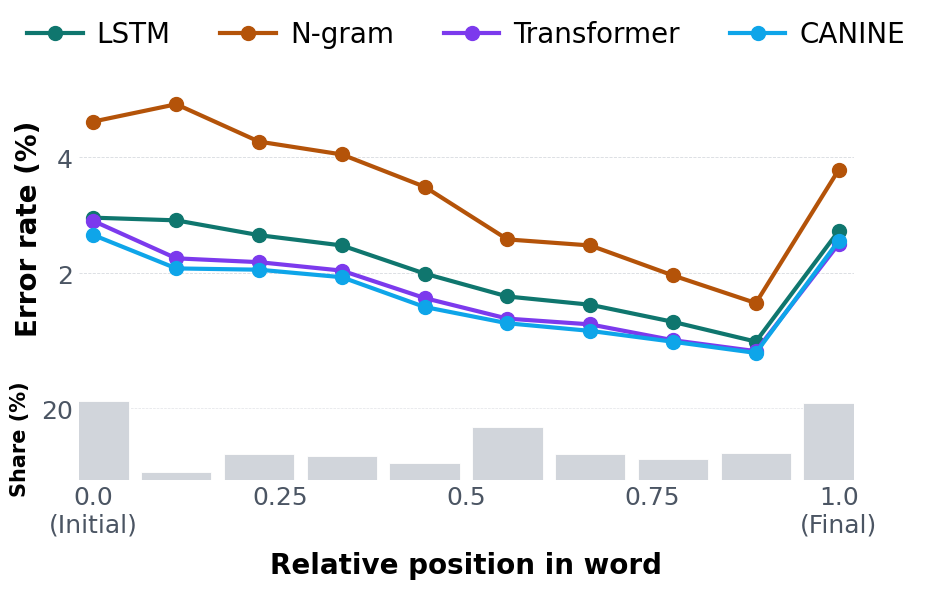

In [7]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Helvetica", "Arial"],
    "font.size": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 20,
    "axes.labelweight": "bold",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGURES_DIR = os.path.join(REPO_ROOT, "tnqeet", "notebooks", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

N_BINS = 10
BIN_EDGES = np.linspace(0.0, 1.0, N_BINS + 1)
# Plot positions span the full [0, 1] interval. Semantically valid because bin 0 catches
# only rel=0 (initial) and bin (N_BINS-1) catches only rel=1 (final) by construction.
PLOT_X = np.linspace(0.0, 1.0, N_BINS)

METHOD_PALETTE = {
    "LSTM (L=6)":            "#0F766E",  # teal
    "N-gram (n=8, beam=60)": "#B45309",  # amber
    "Transformer (L=12)":    "#7C3AED",  # purple
    "CANINE-canine-s":       "#0EA5E9",  # sky
}

# Compact display names for the legend so it fits the figure width without forcing
# bbox_inches="tight" to expand the canvas. Detailed configurations live in Table 1.
LEGEND_NAMES = {
    "LSTM (L=6)":            "LSTM",
    "N-gram (n=8, beam=60)": "N-gram",
    "Transformer (L=12)":    "Transformer",
    "CANINE-canine-s":       "CANINE",
}

# Compute per-method error rate per bin, plus a single shared density (positions per bin).
per_method_err = {}
bin_density = None
for name, _ in METHODS:
    _, rel_records = ANALYSES[name]
    rels = np.array([r for r, _, _ in rel_records])
    correct = np.array([c for _, c, _ in rel_records])
    bin_idx = np.clip(np.searchsorted(BIN_EDGES, rels, side="right") - 1, 0, N_BINS - 1)
    err = np.full(N_BINS, np.nan)
    counts = np.zeros(N_BINS, dtype=int)
    for b in range(N_BINS):
        mask = bin_idx == b
        counts[b] = mask.sum()
        if mask.any():
            err[b] = 100.0 * (1 - correct[mask].mean())
    per_method_err[name] = err
    if bin_density is None:
        bin_density = counts  # density is method-independent (same input positions)

density_pct = 100.0 * bin_density / bin_density.sum()

fig, (ax, ax_density) = plt.subplots(
    2, 1, figsize=(10.0, 5.2), sharex=True,
    gridspec_kw={"height_ratios": [3.6, 1.0], "hspace": 0.1},
)
fig.patch.set_facecolor("white")

# === Top panel: error-rate curves ===
for name, _ in METHODS:
    ax.plot(
        PLOT_X, per_method_err[name],
        marker="o", markersize=10, linewidth=3.0,
        color=METHOD_PALETTE.get(name, "#374151"),
        label=LEGEND_NAMES.get(name, name),
    )

ax.set_ylabel("Error rate (%)", labelpad=10)
ax.set_xlim(-0.02, 1.02)
err_min = min(np.nanmin(v) for v in per_method_err.values())
err_max = max(np.nanmax(v) for v in per_method_err.values())
pad = max(0.2, 0.1 * (err_max - err_min))
ax.set_ylim(max(0, err_min - pad), err_max + pad)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.4, color="#9CA3AF")
ax.set_axisbelow(True)
ax.tick_params(axis="both", which="both", length=0, colors="#4B5563", pad=4)
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(METHODS),
    frameon=False,
    handletextpad=0.5,
    columnspacing=1.8,
)

# === Bottom panel: density of positions per bin ===
bar_step = PLOT_X[1] - PLOT_X[0]
ax_density.bar(
    PLOT_X, density_pct,
    width=bar_step * 0.85,
    color="#D1D5DB", edgecolor="white", linewidth=0.6,
)
ax_density.set_ylabel("Share (%)", fontsize=15, labelpad=8)
ax_density.set_xlabel("Relative position in word", labelpad=10)
ax_density.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax_density.set_xticklabels(["0.0\n(Initial)", "0.25", "0.5", "0.75", "1.0\n(Final)"])
ax_density.set_yticks([20])  # drop the 0 tick — it visually collides with the x-axis "0.0"
for spine in ax_density.spines.values():
    spine.set_visible(False)
ax_density.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.3, color="#9CA3AF")
ax_density.set_axisbelow(True)
ax_density.tick_params(axis="both", which="both", length=0, colors="#4B5563", pad=4)

fig.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "dotting_error_rate_by_relative_position.pdf"), bbox_inches="tight")
plt.show()

## Table 2: per-Rasm accuracy by position category

Wider breakdown — for each method, accuracy at each (Rasm, category) cell. Use to spot Rasms where one position dominates the error budget (e.g. final-`ها` vs `ة`, or initial `ا`/`أ`/`إ`).

In [8]:
frames = []
for name, _ in METHODS:
    cat_counts, *_ = ANALYSES[name]
    rows = []
    for rasm in AMBIGUOUS_RASMS:
        row = [f"{RASM_NAMES[rasm]} ({rasm})"]
        for cat in POSITION_CATEGORIES:
            counts = cat_counts.get((rasm, cat), [0, 0])
            row.append(f"{acc(counts):6.2f}" if counts[1] else "  ----")
        rows.append(row)
    df = pd.DataFrame(rows, columns=["Rasm"] + POSITION_CATEGORIES)
    df.insert(0, "Method", name)
    frames.append(df)

per_rasm_df = pd.concat(frames, ignore_index=True)
for name, _ in METHODS:
    print(f"\n=== {name} ===")
    sub = per_rasm_df[per_rasm_df["Method"] == name].drop(columns=["Method"])
    print(tabulate(sub.values.tolist(), headers=sub.columns.tolist(), tablefmt="github", stralign="center"))


=== LSTM (L=6) ===
|   Rasm   |   isolated |   initial |   medial |   final |
|----------|------------|-----------|----------|---------|
| ALEF (ا) |      84.86 |     94.85 |    97.52 |   99.64 |
| BAA (ٮ)  |      95.59 |     97.37 |    97.08 |   98.02 |
| JEEM (ح) |      50    |     94.87 |    95.68 |   95.72 |
| DAL (د)  |     100    |     98.63 |    98.65 |   99.28 |
| RAA (ر)  |      88.89 |     97.18 |    98.49 |   98.81 |
| SEEN (س) |      83.87 |     95.67 |    97.25 |   97.88 |
| SAAD (ص) |      96.3  |     97.71 |    97.65 |   98.26 |
| TAA (ط)  |     100    |     98.31 |    98.67 |   98.76 |
| AIN (ع)  |      97.8  |     98.49 |    97.67 |   99.35 |
| FAA (ڡ)  |     100    |    100    |   100    |  100    |
| QAF (ٯ)  |     100    |    100    |   100    |  100    |
| NOON (ں) |     100    |    100    |   100    |  100    |
| HAA (ه)  |     100    |    100    |    99.1  |   96.35 |
| WAW (و)  |     100    |    100    |    99.74 |   99.97 |
| YAA (ى)  |     100    |     99.99 